# Telco Customer Churn — Retention Strategy & Business Value

**Goal:** Turn model predictions into a targeting decision, and be honest
about how much that decision depends on assumptions nobody's actually
validated yet.

**Central question:** Can churn predictions support a defensible retention
strategy, and under what economic assumptions does model-based targeting
actually beat simpler alternatives (contact everyone, contact no one)?

This notebook consumes `test_predictions.csv` and `locked_threshold.json`
from `03_modeling_and_evaluation.ipynb` directly — the threshold and model
choice were already made there, on training data only. Nothing here
re-derives or second-guesses that decision; this notebook only asks what to
*do* with the predictions it was handed.

1. Load predictions and locked threshold
2. Define targeting strategies (contact nobody / everyone / top 5% / 10% /
   20% / model's locked threshold)
3. Evaluate each strategy's targeting quality (precision, recall, lift)
4. State business assumptions explicitly as assumptions
5. Expected-value comparison across strategies
6. Sensitivity analysis — does the conclusion survive if the assumptions are wrong?
7. Break-even analysis — under what conditions does the model beat contacting everyone?


## 1. Setup

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
%matplotlib inline


## 2. Load predictions and locked threshold

These come directly from notebook 03 — the model and threshold were chosen
there, using cross-validation on training data only. This notebook treats
both as fixed inputs.


In [2]:
preds = pd.read_csv('../data/test_predictions.csv')

with open('../data/locked_threshold.json') as f:
    threshold_info = json.load(f)

locked_threshold = threshold_info['locked_threshold']
model_name = threshold_info['model']

print(f"Model: {model_name}")
print(f"Locked threshold: {locked_threshold:.2f}")
print(f"Brier score (calibration, from notebook 03): {threshold_info['brier_score']:.4f}")
print(f"Test set: {len(preds):,} customers, {preds['actual'].mean():.1%} actual churn rate")


Model: XGBoost
Locked threshold: 0.50
Brier score (calibration, from notebook 03): 0.1679
Test set: 1,407 customers, 26.6% actual churn rate


## 3. Define targeting strategies

Six strategies, ranked from no targeting effort to full-population contact:

- **Contact nobody** — the do-nothing baseline
- **Contact everyone** — the naive maximum-effort baseline
- **Locked threshold** — the model's own decision rule from notebook 03
- **Top 5% / 10% / 20% by predicted risk** — fixed-capacity targeting, the
  realistic shape of an actual retention campaign (a retention team
  usually has a budget for *N* outreach calls, not "however many the
  threshold happens to flag")


In [3]:
preds_sorted = preds.sort_values('predicted_proba', ascending=False).reset_index(drop=True)
n = len(preds_sorted)

def top_pct_strategy(df, pct):
    cutoff_n = int(np.ceil(len(df) * pct))
    contacted = np.zeros(len(df), dtype=int)
    contacted[:cutoff_n] = 1
    # re-align back to original (unsorted) row order via index
    return pd.Series(contacted, index=df.index)

strategies = {}
strategies['Contact nobody'] = pd.Series(0, index=preds_sorted.index)
strategies['Contact everyone'] = pd.Series(1, index=preds_sorted.index)
strategies['Locked threshold'] = (preds_sorted['predicted_proba'] >= locked_threshold).astype(int)
strategies['Top 5%'] = top_pct_strategy(preds_sorted, 0.05)
strategies['Top 10%'] = top_pct_strategy(preds_sorted, 0.10)
strategies['Top 20%'] = top_pct_strategy(preds_sorted, 0.20)

for name, contacted in strategies.items():
    print(f"{name:<20} contacts {contacted.sum():>4} of {n} customers ({contacted.mean():.1%})")


Contact nobody       contacts    0 of 1407 customers (0.0%)
Contact everyone     contacts 1407 of 1407 customers (100.0%)
Locked threshold     contacts  545 of 1407 customers (38.7%)
Top 5%               contacts   71 of 1407 customers (5.0%)
Top 10%              contacts  141 of 1407 customers (10.0%)
Top 20%              contacts  282 of 1407 customers (20.0%)


## 4. Targeting quality by strategy

For each strategy: how many actual churners does it catch (recall), how
much of the contacted group is actually going to churn (precision), and how
much better is that than random targeting (lift)?


In [4]:
actual = preds_sorted['actual']
base_rate = actual.mean()

quality_rows = []
for name, contacted in strategies.items():
    n_contacted = contacted.sum()
    if n_contacted == 0:
        precision = recall = lift = np.nan
    else:
        tp = ((contacted == 1) & (actual == 1)).sum()
        precision = tp / n_contacted
        recall = tp / actual.sum()
        lift = precision / base_rate if base_rate > 0 else np.nan
    quality_rows.append({
        'Strategy': name,
        'Customers contacted': int(n_contacted),
        'Churners captured': int(((contacted == 1) & (actual == 1)).sum()),
        'Precision': round(precision, 3) if not np.isnan(precision) else None,
        'Recall': round(recall, 3) if not np.isnan(recall) else None,
        'Lift over random': round(lift, 2) if not np.isnan(lift) else None,
    })

quality_df = pd.DataFrame(quality_rows)
quality_df


,Strategy,Customers contacted,Churners captured,Precision,Recall,Lift over random
0,Contact nobody,0,0,NaN,NaN,NaN
1,Contact everyone,1407,374,0.266,1.000,1.00
2,Locked threshold,545,282,0.517,0.754,1.95
3,Top 5%,71,58,0.817,0.155,3.07
4,Top 10%,141,102,0.723,0.273,2.72
5,Top 20%,282,181,0.642,0.484,2.41


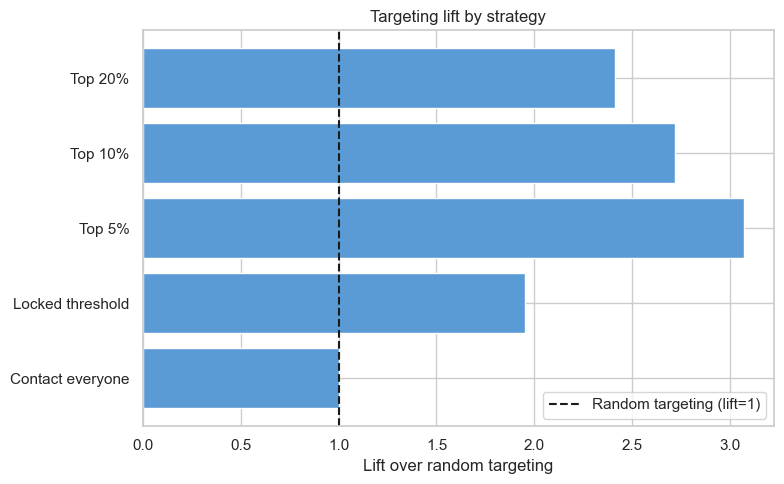

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = quality_df.dropna(subset=['Lift over random'])
ax.barh(plot_df['Strategy'], plot_df['Lift over random'], color='#5B9BD5')
ax.axvline(1.0, color='k', linestyle='--', label='Random targeting (lift=1)')
ax.set_xlabel('Lift over random targeting')
ax.set_title('Targeting lift by strategy')
ax.legend()
plt.tight_layout()
plt.savefig('../data/plots/targeting_lift.png', dpi=150)
plt.show()


## 5. Business assumptions — explicitly labeled

These three numbers are **illustrative, not real business figures** — nobody
validated them against actual company data. Every result below is
conditional on them. That's the point of Section 6.

| Parameter | Base case | What it represents |
|---|---|---|
| Customer lifetime value (CLV) | $1,200 | $ value saved if a churner is retained |
| Retention offer cost | $50 | Cost per customer contacted with a retention offer |
| Retention success rate | 30% | Probability a *true* churner who is contacted actually stays |

If you have real figures for these (from finance, marketing, or a past
campaign), replace them here — everything downstream recalculates
automatically.


In [6]:
CLV_BASE = 1_200
OFFER_COST_BASE = 50
RETAIN_RATE_BASE = 0.30

def expected_value(contacted, actual, clv, offer_cost, retain_rate):
    tp = ((contacted == 1) & (actual == 1)).sum()
    n_contacted = contacted.sum()
    revenue_saved = tp * retain_rate * clv
    total_cost = n_contacted * offer_cost
    return revenue_saved - total_cost, revenue_saved, total_cost


## 6. Expected value by strategy, at base-case assumptions

In [7]:
value_rows = []
for name, contacted in strategies.items():
    net, revenue, cost = expected_value(contacted, actual, CLV_BASE, OFFER_COST_BASE, RETAIN_RATE_BASE)
    value_rows.append({
        'Strategy': name,
        'Revenue saved': round(revenue),
        'Offer cost': round(cost),
        'Net value': round(net),
    })

value_df = pd.DataFrame(value_rows).sort_values('Net value', ascending=False).reset_index(drop=True)
value_df


,Strategy,Revenue saved,Offer cost,Net value
0,Locked threshold,101520,27250,74270
1,Contact everyone,134640,70350,64290
2,Top 20%,65160,14100,51060
3,Top 10%,36720,7050,29670
4,Top 5%,20880,3550,17330
5,Contact nobody,0,0,0


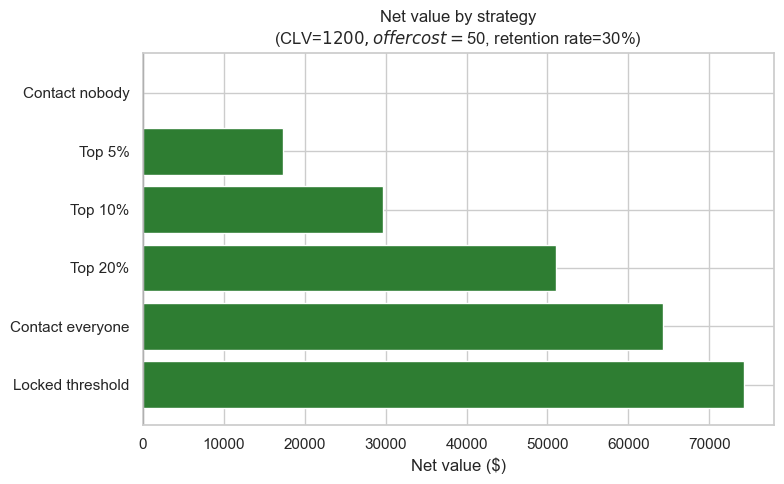

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2E7D32' if v >= 0 else '#C62828' for v in value_df['Net value']]
ax.barh(value_df['Strategy'], value_df['Net value'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Net value ($)')
ax.set_title(f'Net value by strategy\n(CLV=${CLV_BASE}, offer cost=${OFFER_COST_BASE}, retention rate={RETAIN_RATE_BASE:.0%})')
plt.tight_layout()
plt.savefig('../data/plots/net_value_by_strategy.png', dpi=150)
plt.show()


## 6b. Export strategy scenarios for Power BI

One row per strategy, combining targeting quality (Section 4) and expected
value (Section 6) into a single table — this is the source for the
Retention Strategy dashboard page, where a slicer lets the viewer switch
between strategies.


In [9]:
strategy_export = quality_df.merge(value_df, on='Strategy')
strategy_export.to_csv('../data/retention_strategy_scenarios.csv', index=False)
print(f"Saved retention_strategy_scenarios.csv  ({strategy_export.shape[0]} rows)")
strategy_export


Saved retention_strategy_scenarios.csv  (6 rows)


,Strategy,Customers contacted,Churners captured,Precision,Recall,Lift over random,Revenue saved,Offer cost,Net value
0,Contact nobody,0,0,NaN,NaN,NaN,0,0,0
1,Contact everyone,1407,374,0.266,1.000,1.00,134640,70350,64290
2,Locked threshold,545,282,0.517,0.754,1.95,101520,27250,74270
3,Top 5%,71,58,0.817,0.155,3.07,20880,3550,17330
4,Top 10%,141,102,0.723,0.273,2.72,36720,7050,29670
5,Top 20%,282,181,0.642,0.484,2.41,65160,14100,51060


✍️ **YOUR INTERPRETATION HERE**

- Which strategy wins at base-case assumptions? Is it one of the model-based
  ones, or does "contact everyone" actually win here?
- If a fixed-capacity strategy (top 10%, say) wins over the locked threshold,
  what does that say about how a real retention team should operationalize
  this — as a threshold rule, or as "call your top N highest-risk customers"?


## 7. Sensitivity analysis

Base-case numbers are made up. The real question: **does the ranking of
strategies survive if those numbers are wrong?**

Two views, deliberately scoped rather than an exhaustive grid search:

1. **One-at-a-time** — vary each assumption alone (low / base / high),
   holding the other two fixed, for the strategy that won in Section 6.
   Shows which assumption the conclusion is most sensitive to.
2. **Two-way heatmap** — CLV × retention rate (the two parameters likely to
   vary most in reality), at the base-case offer cost, comparing the winning
   model-based strategy against "contact everyone."


In [10]:
best_strategy_name = value_df.iloc[0]['Strategy']
best_contacted = strategies[best_strategy_name]
print(f"Running sensitivity analysis on the Section 6 winner: '{best_strategy_name}'")


Running sensitivity analysis on the Section 6 winner: 'Locked threshold'


In [11]:
# ── One-at-a-time sensitivity ────────────────────────────────────────────────
scenarios = {
    'CLV': [(800, OFFER_COST_BASE, RETAIN_RATE_BASE), (1_200, OFFER_COST_BASE, RETAIN_RATE_BASE), (1_600, OFFER_COST_BASE, RETAIN_RATE_BASE)],
    'Offer cost': [(CLV_BASE, 30, RETAIN_RATE_BASE), (CLV_BASE, 50, RETAIN_RATE_BASE), (CLV_BASE, 80, RETAIN_RATE_BASE)],
    'Retention rate': [(CLV_BASE, OFFER_COST_BASE, 0.20), (CLV_BASE, OFFER_COST_BASE, 0.30), (CLV_BASE, OFFER_COST_BASE, 0.40)],
}

sens_rows = []
for param_name, combos in scenarios.items():
    for clv, cost, rate in combos:
        net_best, _, _ = expected_value(best_contacted, actual, clv, cost, rate)
        net_everyone, _, _ = expected_value(strategies['Contact everyone'], actual, clv, cost, rate)
        sens_rows.append({
            'Varying': param_name,
            'CLV': clv, 'Offer cost': cost, 'Retention rate': rate,
            f'Net value ({best_strategy_name})': round(net_best),
            'Net value (Contact everyone)': round(net_everyone),
            'Model-based wins?': net_best > net_everyone,
        })

sens_df = pd.DataFrame(sens_rows)
sens_df


,Varying,CLV,Offer cost,Retention rate,Net value (Locked threshold),Net value (Contact everyone),Model-based wins?
0,CLV,800,50,0.3,40430,19410,True
1,CLV,1200,50,0.3,74270,64290,True
2,CLV,1600,50,0.3,108110,109170,False
3,Offer cost,1200,30,0.3,85170,92430,False
4,Offer cost,1200,50,0.3,74270,64290,True
5,Offer cost,1200,80,0.3,57920,22080,True
6,Retention rate,1200,50,0.2,40430,19410,True
7,Retention rate,1200,50,0.3,74270,64290,True
8,Retention rate,1200,50,0.4,108110,109170,False


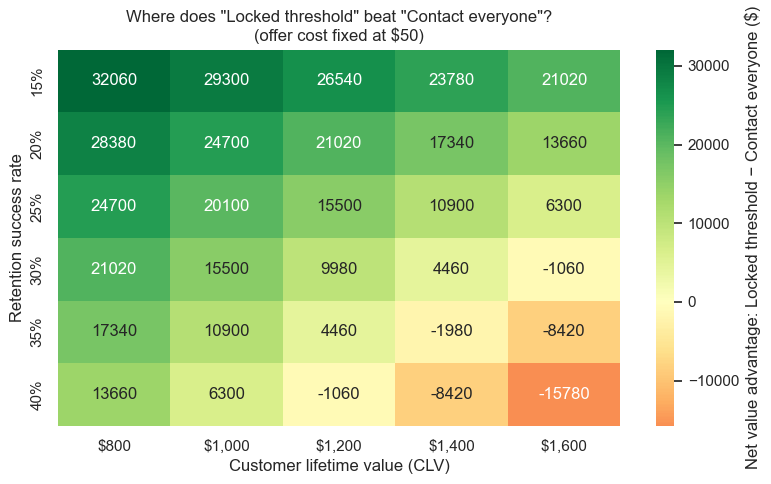

In [12]:
# ── Two-way heatmap: CLV x retention rate, offer cost fixed at base ──────────
clv_range = [800, 1_000, 1_200, 1_400, 1_600]
retain_range = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40]

heatmap_data = np.zeros((len(retain_range), len(clv_range)))
for i, rate in enumerate(retain_range):
    for j, clv in enumerate(clv_range):
        net_best, _, _ = expected_value(best_contacted, actual, clv, OFFER_COST_BASE, rate)
        net_everyone, _, _ = expected_value(strategies['Contact everyone'], actual, clv, OFFER_COST_BASE, rate)
        heatmap_data[i, j] = net_best - net_everyone  # positive = model-based strategy wins

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    heatmap_data, annot=True, fmt='.0f', cmap='RdYlGn', center=0,
    xticklabels=[f'${c:,}' for c in clv_range],
    yticklabels=[f'{r:.0%}' for r in retain_range],
    ax=ax, cbar_kws={'label': f'Net value advantage: {best_strategy_name} − Contact everyone ($)'},
)
ax.set_xlabel('Customer lifetime value (CLV)')
ax.set_ylabel('Retention success rate')
ax.set_title(f'Where does "{best_strategy_name}" beat "Contact everyone"?\n(offer cost fixed at ${OFFER_COST_BASE})')
plt.tight_layout()
plt.savefig('../data/plots/sensitivity_heatmap.png', dpi=150)
plt.show()


✍️ **YOUR INTERPRETATION HERE**

- From the one-at-a-time table: which single assumption, if wrong, flips the
  conclusion? That's the number worth getting right first if this were a
  real deployment.
- From the heatmap: is there a region (low CLV, low retention rate) where
  "contact everyone" actually wins? What does that mean practically — that
  targeting only pays off above some minimum customer value?


## 8. Break-even analysis

Rather than eyeballing the heatmap, solve directly: at base-case CLV and
offer cost, what retention success rate is the break-even point where the
best model-based strategy exactly matches "contact everyone"?


Break-even retention success rate (CLV=$1200, offer cost=$50): ~39%
Below this, 'Contact everyone' wins. Above it, 'Locked threshold' wins.


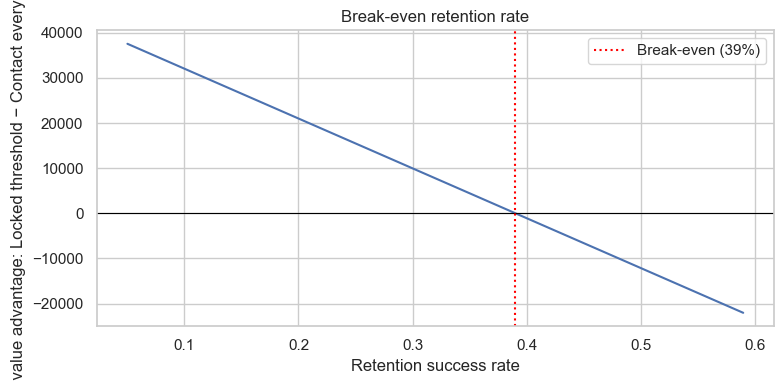

In [13]:
rates_fine = np.arange(0.05, 0.60, 0.01)
diffs = []
for rate in rates_fine:
    net_best, _, _ = expected_value(best_contacted, actual, CLV_BASE, OFFER_COST_BASE, rate)
    net_everyone, _, _ = expected_value(strategies['Contact everyone'], actual, CLV_BASE, OFFER_COST_BASE, rate)
    diffs.append(net_best - net_everyone)

diffs = np.array(diffs)
sign_changes = np.where(np.diff(np.sign(diffs)) != 0)[0]

if len(sign_changes) > 0:
    breakeven_rate = rates_fine[sign_changes[0]]
    print(f"Break-even retention success rate (CLV=${CLV_BASE}, offer cost=${OFFER_COST_BASE}): ~{breakeven_rate:.0%}")
    print(f"Below this, 'Contact everyone' wins. Above it, '{best_strategy_name}' wins.")
else:
    winner = best_strategy_name if diffs[0] > 0 else 'Contact everyone'
    print(f"'{winner}' wins across the entire 5%–60% retention rate range tested at these CLV/cost assumptions.")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(rates_fine, diffs)
ax.axhline(0, color='black', linewidth=0.8)
if len(sign_changes) > 0:
    ax.axvline(breakeven_rate, color='red', linestyle=':', label=f'Break-even ({breakeven_rate:.0%})')
    ax.legend()
ax.set_xlabel('Retention success rate')
ax.set_ylabel(f'Net value advantage: {best_strategy_name} − Contact everyone ($)')
ax.set_title('Break-even retention rate')
plt.tight_layout()
plt.savefig('../data/plots/breakeven_analysis.png', dpi=150)
plt.show()


## 9. Summary

**Central question, answered:** *(fill in once run — does model-based
targeting beat the naive alternatives, and under what conditions?)*

**Key findings:**
- Winning strategy at base-case assumptions: *(fill in from Section 6)*
- Assumption the conclusion is most sensitive to: *(fill in from Section 7)*
- Break-even retention rate: *(fill in from Section 8)*

**Honest framing for a portfolio README:** this notebook doesn't claim to
know the real CLV, offer cost, or retention rate for an actual business —
it demonstrates the methodology for turning a calibrated model into a
defensible targeting decision, and for stress-testing that decision against
assumption uncertainty, which is the part that transfers to a real business
context regardless of what the true numbers turn out to be.
